# Análise Exploratória de Dados — Futuros de Café Arábica (KC=F)

Notebook de EDA do dataset `data/dataset_final.csv`, que combina preço de fechamento
dos futuros de café arábica, câmbio BRL/USD e variáveis climáticas de 4 estações INMET
das microrregiões produtoras de Minas Gerais (**Varginha, Patrocínio, Manhuaçu, Machado**).

O alvo da modelagem é o **log-retorno** do preço, $r_t = \ln(P_t / P_{t-1})$, e não o nível bruto.

Todas as figuras são salvas em `figures/` em alta resolução (dpi=150) com títulos e eixos rotulados.
Cada bloco imprime um comentário curto interpretando o que o gráfico mostra.


## 0. Configuração e carregamento

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

warnings.filterwarnings("ignore")

# Estilo de publicação
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 200,
    "savefig.bbox": "tight",
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "figure.titlesize": 14,
})

FIGDIR = "figures"
os.makedirs(FIGDIR, exist_ok=True)

def savefig(fig, name):
    path = os.path.join(FIGDIR, name)
    fig.savefig(path, dpi=200)
    print(f"  [figura salva] {path}")

# Estações e prefixos das variáveis climáticas
STATIONS = ["Varginha", "Patrocinio", "Manhuacu", "Machado"]
CLIM_PREFIX = {
    "temp_min_C_min": "Temp. mínima (°C)",
    "temp_ar_C_mean": "Temp. média do ar (°C)",
    "umidade_pct_mean": "Umidade relativa (%)",
    "precip_mm_sum": "Precipitação (mm)",
    "radiacao_kJm2_sum": "Radiação (kJ/m²)",
    "graus_frio": "Graus-frio",
    "geada_risco": "Risco de geada (0/1)",
}


In [2]:
df = pd.read_csv("data/dataset_final.csv", parse_dates=["date"])
df = df.sort_values("date").reset_index(drop=True)
df = df.set_index("date")

# Log-retorno do preço (alvo da modelagem)
df["log_ret"] = np.log(df["preco_cafe"] / df["preco_cafe"].shift(1))

print(f"Linhas: {df.shape[0]}  |  Colunas: {df.shape[1]}")
print(f"Período: {df.index.min().date()} -> {df.index.max().date()}")
df.head(3)


Linhas: 1763  |  Colunas: 47
Período: 2018-12-31 -> 2025-12-30


,preco_cafe,cambio_brl,geada_risco_Machado,geada_risco_Manhuacu,geada_risco_Patrocinio,geada_risco_Varginha,graus_frio_Machado,graus_frio_Manhuacu,graus_frio_Patrocinio,graus_frio_Varginha,...,umidade_pct_mean_Varginha,vento_rajada_ms_max_Machado,vento_rajada_ms_max_Manhuacu,vento_rajada_ms_max_Patrocinio,vento_rajada_ms_max_Varginha,vento_vel_ms_mean_Machado,vento_vel_ms_mean_Manhuacu,vento_vel_ms_mean_Patrocinio,vento_vel_ms_mean_Varginha,log_ret
date,,,,,,,,,,,,,,,,,,,,,
2018-12-31,101.849998,3.8742,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,77.000000,10.6,8.6,11.6,8.95,1.222917,2.014583,1.38125,1.737500,NaN
2019-01-02,99.500000,3.8799,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,77.000000,10.6,8.6,11.6,8.95,1.222917,2.014583,1.38125,1.737500,-0.023343
2019-01-03,102.150002,3.7863,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,80.208333,15.3,11.7,8.9,11.60,1.716667,1.729167,1.22500,1.891667,0.026285


## 1. Visão geral

Shape, período coberto, dtypes, % de valores faltantes, estatísticas descritivas e
mapa de valores faltantes ao longo do tempo.

In [3]:
# Shape, período e dtypes
print(f"Shape: {df.shape}")
print(f"Período coberto: {df.index.min().date()} a {df.index.max().date()} "
      f"({(df.index.max()-df.index.min()).days} dias de calendário, {len(df)} observações úteis)")
print(f"Datas duplicadas: {df.index.duplicated().sum()}")
print("\nContagem de dtypes:")
print(df.dtypes.value_counts())


Shape: (1763, 47)
Período coberto: 2018-12-31 a 2025-12-30 (2556 dias de calendário, 1763 observações úteis)
Datas duplicadas: 0

Contagem de dtypes:
float64    47
Name: count, dtype: int64


In [4]:
# % de valores faltantes por coluna
na_pct = (df.isna().mean() * 100).sort_values(ascending=False)
print("% de valores faltantes por coluna (top 15):")
print(na_pct.head(15).round(3))
print(f"\nTotal de colunas com algum NA: {(na_pct > 0).sum()}")
print("Obs.: o único NA esperado é o primeiro log-retorno (sem P_{t-1}).")


% de valores faltantes por coluna (top 15):
log_ret                     0.057
cambio_brl                  0.000
preco_cafe                  0.000
geada_risco_Manhuacu        0.000
geada_risco_Patrocinio      0.000
geada_risco_Varginha        0.000
geada_risco_Machado         0.000
graus_frio_Manhuacu         0.000
graus_frio_Patrocinio       0.000
graus_frio_Varginha         0.000
precip_mm_sum_Machado       0.000
precip_mm_sum_Manhuacu      0.000
precip_mm_sum_Patrocinio    0.000
precip_mm_sum_Varginha      0.000
graus_frio_Machado          0.000
dtype: float64

Total de colunas com algum NA: 1
Obs.: o único NA esperado é o primeiro log-retorno (sem P_{t-1}).


In [5]:
# Estatísticas descritivas: preço, câmbio e log-retornos
desc = df[["preco_cafe", "cambio_brl", "log_ret"]].describe(percentiles=[.01, .05, .5, .95, .99])
print("Estatísticas descritivas — preço, câmbio e log-retorno:")
print(desc.round(5))

# Momentos extras do log-retorno
lr = df["log_ret"].dropna()
print(f"\nLog-retorno  ->  assimetria (skew): {lr.skew():.3f}  |  curtose (excess): {lr.kurtosis():.3f}")
print(f"Retorno diário médio: {lr.mean()*100:.4f}%  |  desvio-padrão diário: {lr.std()*100:.3f}%")
print(f"Volatilidade anualizada (sqrt 252): {lr.std()*np.sqrt(252)*100:.1f}%")
print("\n# Comentário: log-retornos têm média ~0 e assimetria ~0 (quase simétricos), com "
      "curtose em excesso positiva porém MODERADA (~0.7) — levemente leptocúrticos. "
      "Há mais massa no centro e caudas um pouco mais pesadas que a Normal, mas o desvio "
      "é modesto (não é uma distribuição de caudas extremas).")


Estatísticas descritivas — preço, câmbio e log-retorno:
       preco_cafe  cambio_brl     log_ret
count  1763.00000  1763.00000  1762.00000
mean    195.72025     5.08793     0.00070
std      88.22758     0.57453     0.02261
min      86.65000     3.64280    -0.09021
1%       90.43100     3.72177    -0.05287
5%       95.30500     3.84860    -0.03578
50%     182.75000     5.21330     0.00000
95%     390.69501     5.77720     0.03816
99%     413.48800     6.08576     0.05670
max     438.89999     6.30000     0.09557

Log-retorno  ->  assimetria (skew): 0.079  |  curtose (excess): 0.744
Retorno diário médio: 0.0701%  |  desvio-padrão diário: 2.261%
Volatilidade anualizada (sqrt 252): 35.9%

# Comentário: log-retornos têm média ~0 e assimetria ~0 (quase simétricos), com curtose em excesso positiva porém MODERADA (~0.7) — levemente leptocúrticos. Há mais massa no centro e caudas um pouco mais pesadas que a Normal, mas o desvio é modesto (não é uma distribuição de caudas extremas).


  [figura salva] figures/01_missing_map.png


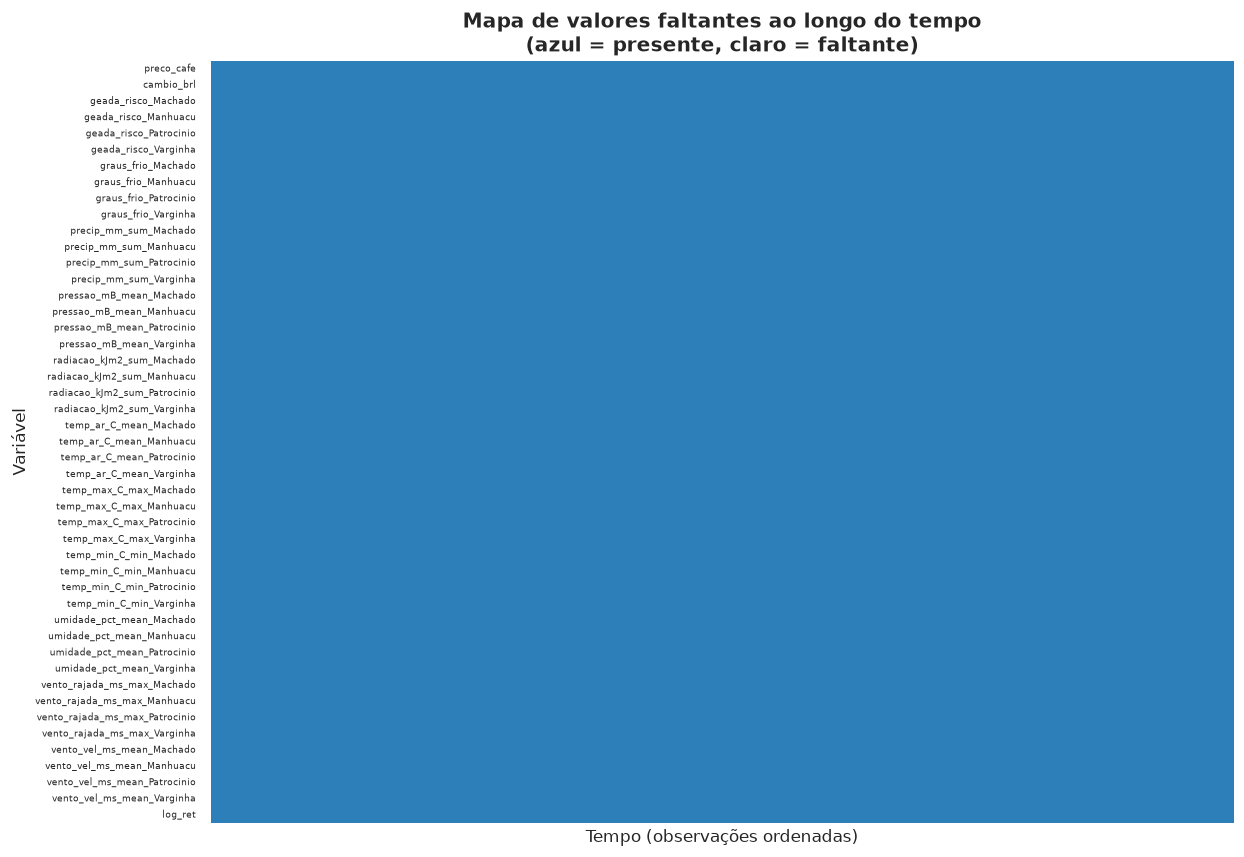


# Comentário: total de células faltantes = 1 (apenas o 1º log-retorno). O dataset é denso/completo. ATENÇÃO: variáveis climáticas têm poucos valores únicos relativos ao nº de linhas (ex.: temp_min Machado = 200 únicos em 1763 linhas), indicando preenchimento (forward-fill) nos dias sem pregão — não há NA, mas há repetição.


In [6]:
# Mapa de valores faltantes ao longo do tempo
fig, ax = plt.subplots(figsize=(12, 9))
miss = df.isna().T  # colunas x tempo
sns.heatmap(miss, cbar=False, cmap=["#2c7fb8", "#fde0dd"],
            xticklabels=False, yticklabels=True, ax=ax)
ax.set_title("Mapa de valores faltantes ao longo do tempo\n(azul = presente, claro = faltante)")
ax.set_xlabel("Tempo (observações ordenadas)")
ax.set_ylabel("Variável")
ax.tick_params(axis="y", labelsize=6)
savefig(fig, "01_missing_map.png")
plt.show()

total_na = df.isna().sum().sum()
print(f"\n# Comentário: total de células faltantes = {total_na} "
      f"(apenas o 1º log-retorno). O dataset é denso/completo. ATENÇÃO: variáveis "
      "climáticas têm poucos valores únicos relativos ao nº de linhas (ex.: "
      f"temp_min Machado = {df['temp_min_C_min_Machado'].nunique()} únicos em {len(df)} linhas), "
      "indicando preenchimento (forward-fill) nos dias sem pregão — não há NA, mas há repetição.")


## 2. Série do preço

Nível, log-retorno, distribuição (histograma + QQ-plot) e testes de estacionariedade (ADF).

  [figura salva] figures/02_preco_nivel.png


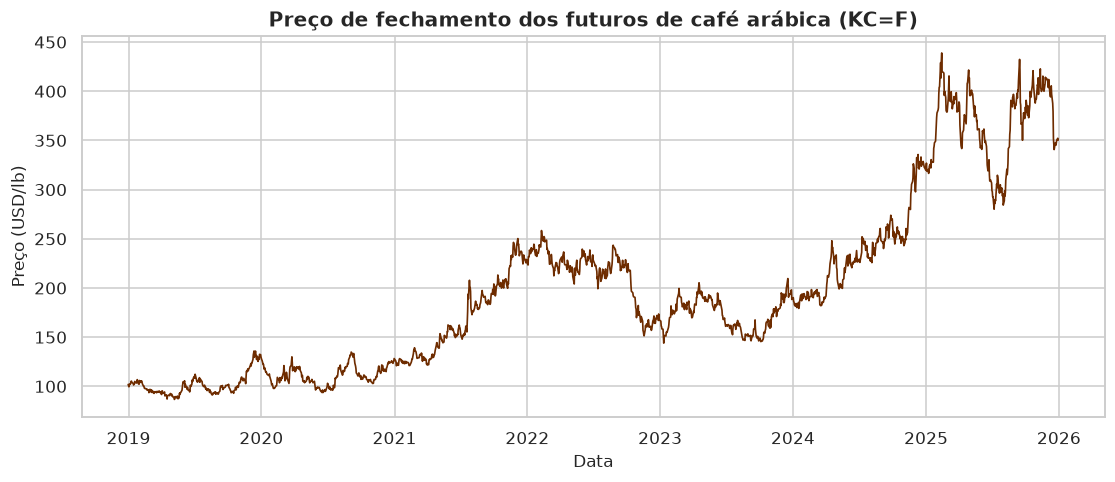


# Comentário: o preço varia de 86.7 a 438.9 USD/lb. Há clara tendência de alta e níveis recordes no fim da amostra (2024-2025), com a série fortemente não-estacionária no nível — média e variância mudam ao longo do tempo.


In [7]:
# Preço de fechamento (nível) ao longo do tempo
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(df.index, df["preco_cafe"], color="#6e2c00", lw=1.1)
ax.set_title("Preço de fechamento dos futuros de café arábica (KC=F)")
ax.set_xlabel("Data")
ax.set_ylabel("Preço (USD/lb)")
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
savefig(fig, "02_preco_nivel.png")
plt.show()

pmin, pmax = df["preco_cafe"].min(), df["preco_cafe"].max()
print(f"\n# Comentário: o preço varia de {pmin:.1f} a {pmax:.1f} USD/lb. Há clara tendência de "
      "alta e níveis recordes no fim da amostra (2024-2025), com a série fortemente "
      "não-estacionária no nível — média e variância mudam ao longo do tempo.")


  [figura salva] figures/03_log_retorno.png


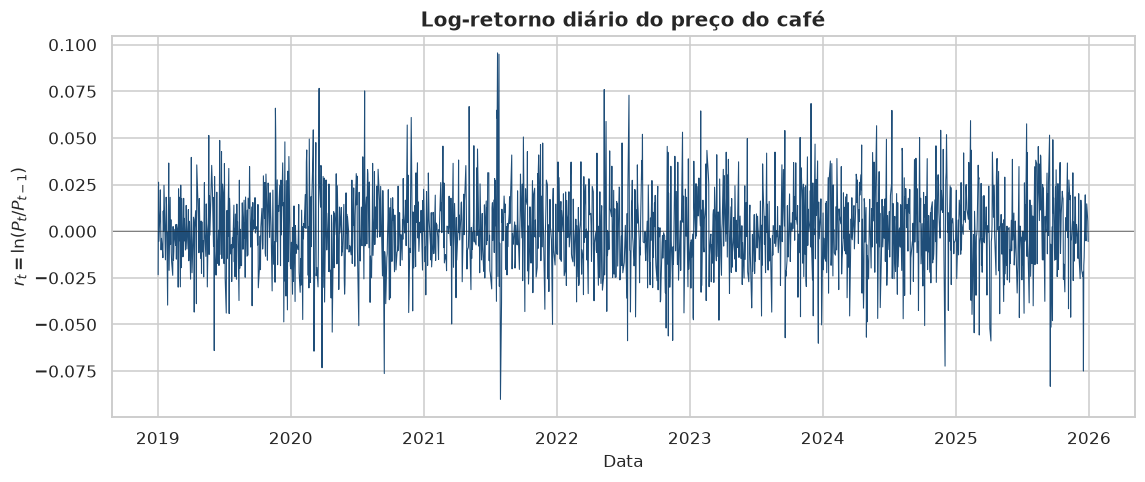


# Comentário: o log-retorno oscila em torno de zero, sem tendência aparente. Visíveis 'aglomerados' de alta volatilidade (períodos agitados seguidos de calmaria) — volatility clustering, que motiva modelos que capturem variância condicional.


In [8]:
# Log-retorno ao longo do tempo
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(df.index, df["log_ret"], color="#1f4e79", lw=0.7)
ax.axhline(0, color="k", lw=0.6, alpha=0.5)
ax.set_title("Log-retorno diário do preço do café")
ax.set_xlabel("Data")
ax.set_ylabel(r"$r_t = \ln(P_t / P_{t-1})$")
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
savefig(fig, "03_log_retorno.png")
plt.show()

print("\n# Comentário: o log-retorno oscila em torno de zero, sem tendência aparente. "
      "Visíveis 'aglomerados' de alta volatilidade (períodos agitados seguidos de calmaria) "
      "— volatility clustering, que motiva modelos que capturem variância condicional.")


  [figura salva] figures/04_hist_qqplot.png


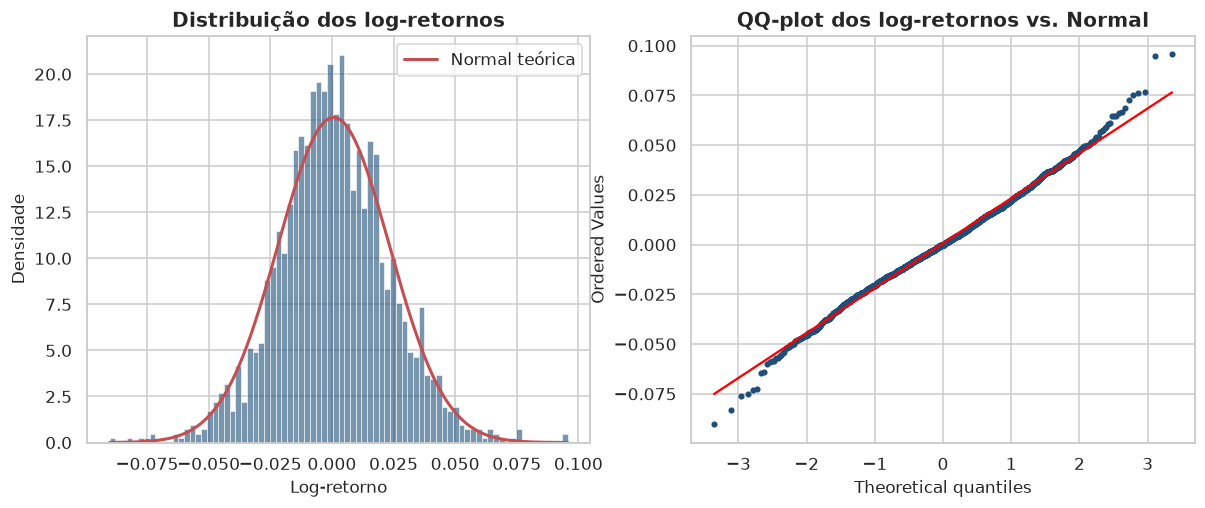


Jarque-Bera: estat=41.8, p-valor=8.21e-10
# Comentário: o pico central é um pouco mais alto que a Normal e as caudas do QQ-plot desviam da reta nos extremos (pontos abaixo à esquerda / acima à direita). Distribuição levemente leptocúrtica; Jarque-Bera rejeita normalidade (p<<0.05), mas o afastamento da Normal é modesto. Prudente não assumir erros estritamente Gaussianos.


In [9]:
# Histograma + QQ-plot dos log-retornos (normalidade visual)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

# Histograma com Normal teórica sobreposta
sns.histplot(lr, bins=80, stat="density", color="#1f4e79", alpha=0.6, ax=axes[0])
x = np.linspace(lr.min(), lr.max(), 300)
axes[0].plot(x, stats.norm.pdf(x, lr.mean(), lr.std()), "r-", lw=2, label="Normal teórica")
axes[0].set_title("Distribuição dos log-retornos")
axes[0].set_xlabel("Log-retorno"); axes[0].set_ylabel("Densidade")
axes[0].legend()

# QQ-plot
stats.probplot(lr, dist="norm", plot=axes[1])
axes[1].get_lines()[0].set_markerfacecolor("#1f4e79")
axes[1].get_lines()[0].set_markeredgecolor("#1f4e79")
axes[1].get_lines()[0].set_markersize(3)
axes[1].get_lines()[1].set_color("red")
axes[1].set_title("QQ-plot dos log-retornos vs. Normal")
savefig(fig, "04_hist_qqplot.png")
plt.show()

# Teste formal de normalidade (Jarque-Bera) para apoiar a leitura visual
jb_stat, jb_p = stats.jarque_bera(lr)
print(f"\nJarque-Bera: estat={jb_stat:.1f}, p-valor={jb_p:.2e}")
print("# Comentário: o pico central é um pouco mais alto que a Normal e as caudas do QQ-plot "
      "desviam da reta nos extremos (pontos abaixo à esquerda / acima à direita). "
      "Distribuição levemente leptocúrtica; Jarque-Bera rejeita normalidade (p<<0.05), "
      "mas o afastamento da Normal é modesto. Prudente não assumir erros estritamente Gaussianos.")


In [10]:
# Teste ADF de estacionariedade: nível vs. log-retorno
def adf_report(series, nome):
    series = series.dropna()
    stat, p, lags, nobs, crit, _ = adfuller(series, autolag="AIC")
    print(f"ADF — {nome}")
    print(f"   estatística = {stat:.4f}  |  p-valor = {p:.4g}  |  lags = {lags}  |  n = {nobs}")
    for k, v in crit.items():
        print(f"   valor crítico {k}: {v:.3f}")
    decisao = "ESTACIONÁRIA (rejeita raiz unitária)" if p < 0.05 else "NÃO-estacionária (não rejeita raiz unitária)"
    print(f"   => {decisao}\n")
    return p

p_nivel = adf_report(df["preco_cafe"], "Preço (nível)")
p_ret   = adf_report(df["log_ret"], "Log-retorno")

print("# Comentário: o nível do preço é não-estacionário (p >> 0.05), enquanto o log-retorno "
      "é estacionário (p < 0.05). Isso confirma a escolha de modelar o log-retorno (I(1) -> "
      "diferença log estaciona a série), pré-requisito para ARIMA e para estabilidade do alvo da LSTM.")


ADF — Preço (nível)
   estatística = -0.8587  |  p-valor = 0.8013  |  lags = 6  |  n = 1756
   valor crítico 1%: -3.434
   valor crítico 5%: -2.863
   valor crítico 10%: -2.568
   => NÃO-estacionária (não rejeita raiz unitária)

ADF — Log-retorno
   estatística = -28.8973  |  p-valor = 0  |  lags = 1  |  n = 1760
   valor crítico 1%: -3.434
   valor crítico 5%: -2.863
   valor crítico 10%: -2.568
   => ESTACIONÁRIA (rejeita raiz unitária)

# Comentário: o nível do preço é não-estacionário (p >> 0.05), enquanto o log-retorno é estacionário (p < 0.05). Isso confirma a escolha de modelar o log-retorno (I(1) -> diferença log estaciona a série), pré-requisito para ARIMA e para estabilidade do alvo da LSTM.


## 3. Estrutura temporal

ACF/PACF do log-retorno (útil p/ escolher ordem do ARIMA depois) e volatilidade rolling
(desvio-padrão de 21 dias) evidenciando clustering.

  [figura salva] figures/05_acf_pacf.png


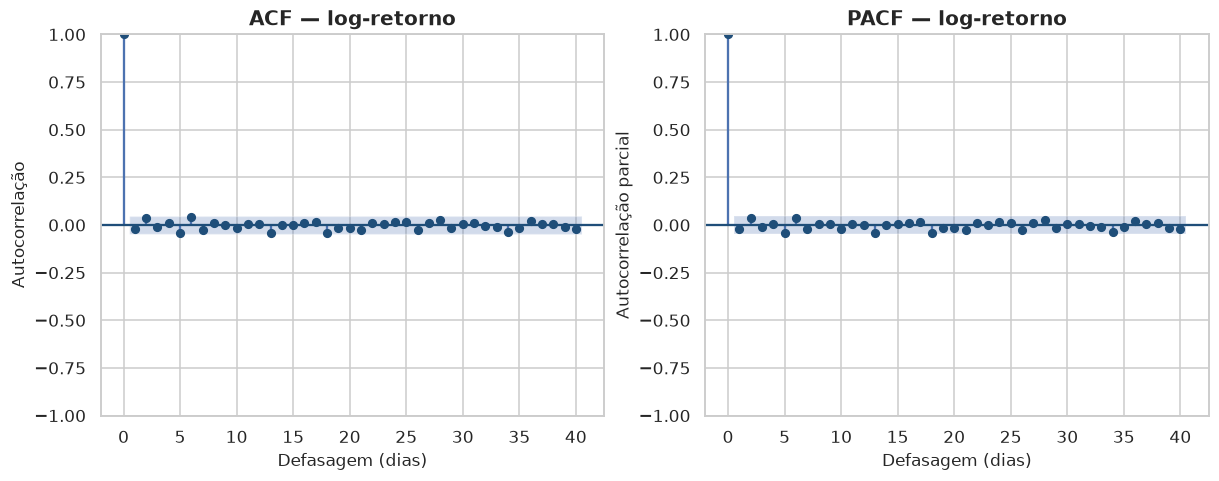


# Comentário: ACF e PACF do log-retorno ficam quase todas dentro da banda de significância — pouca autocorrelação linear na MÉDIA (retornos ~ ruído branco). Sugere ordens baixas de ARIMA (p,q pequenos). A dependência relevante tende a estar na VARIÂNCIA (ver volatilidade abaixo), não na média — o que favorece a LSTM/GARCH.


In [11]:
# ACF e PACF do log-retorno
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
plot_acf(lr, lags=40, ax=axes[0], color="#1f4e79")
axes[0].set_title("ACF — log-retorno")
axes[0].set_xlabel("Defasagem (dias)"); axes[0].set_ylabel("Autocorrelação")
plot_pacf(lr, lags=40, ax=axes[1], method="ywm", color="#1f4e79")
axes[1].set_title("PACF — log-retorno")
axes[1].set_xlabel("Defasagem (dias)"); axes[1].set_ylabel("Autocorrelação parcial")
savefig(fig, "05_acf_pacf.png")
plt.show()

print("\n# Comentário: ACF e PACF do log-retorno ficam quase todas dentro da banda de "
      "significância — pouca autocorrelação linear na MÉDIA (retornos ~ ruído branco). "
      "Sugere ordens baixas de ARIMA (p,q pequenos). A dependência relevante tende a estar "
      "na VARIÂNCIA (ver volatilidade abaixo), não na média — o que favorece a LSTM/GARCH.")


  [figura salva] figures/06_acf_retorno2.png


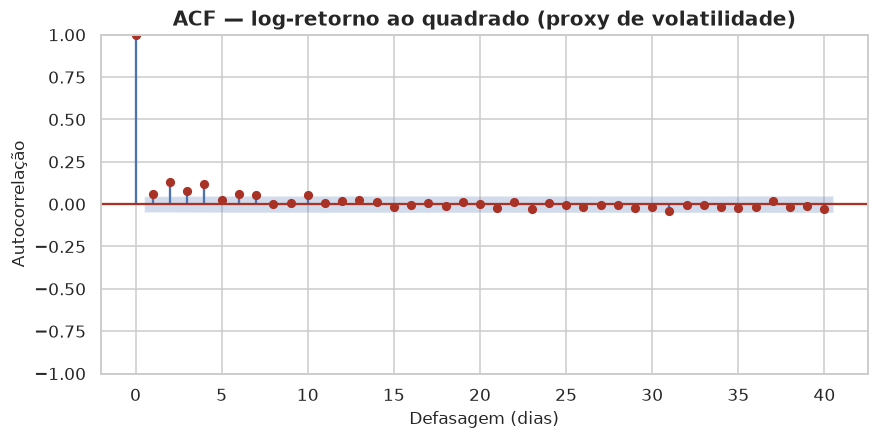


# Comentário: ao contrário dos retornos, os retornos AO QUADRADO mostram autocorrelação significativa e persistente em várias defasagens — confirmação estatística do volatility clustering e da memória longa na variância.


In [12]:
# ACF dos log-retornos AO QUADRADO — evidência de dependência na variância
fig, ax = plt.subplots(figsize=(9, 4))
plot_acf(lr**2, lags=40, ax=ax, color="#a93226")
ax.set_title("ACF — log-retorno ao quadrado (proxy de volatilidade)")
ax.set_xlabel("Defasagem (dias)"); ax.set_ylabel("Autocorrelação")
savefig(fig, "06_acf_retorno2.png")
plt.show()

print("\n# Comentário: ao contrário dos retornos, os retornos AO QUADRADO mostram "
      "autocorrelação significativa e persistente em várias defasagens — confirmação "
      "estatística do volatility clustering e da memória longa na variância.")


  [figura salva] figures/07_volatilidade_rolling.png


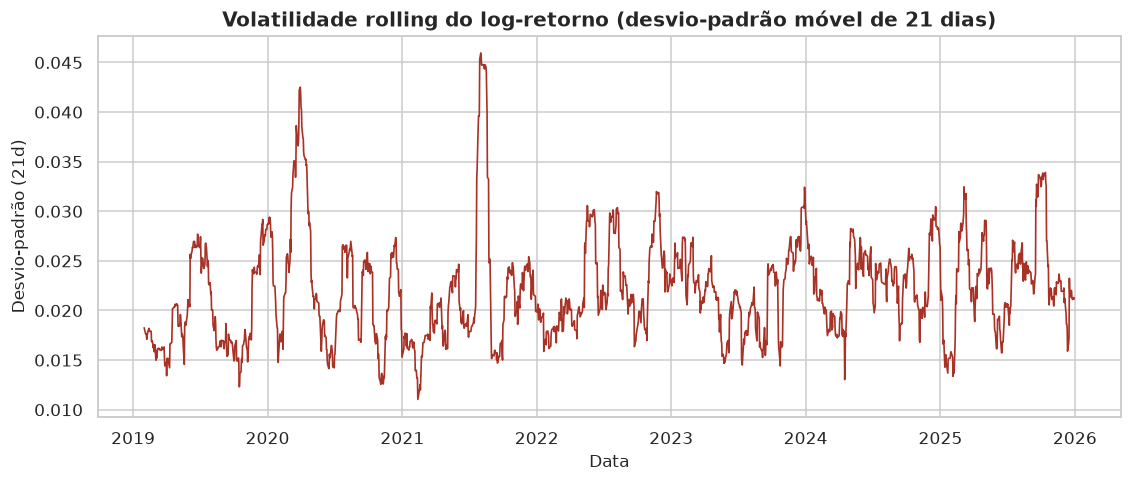


# Comentário: a volatilidade NÃO é constante (heterocedasticidade) — alterna entre regimes calmos e turbulentos, com picos concentrados. Modelar/condicionar à volatilidade (ou deixar a LSTM aprendê-la via janelas) é importante.


In [13]:
# Volatilidade rolling (desvio-padrão de 21 dias ~ 1 mês de pregão)
roll_vol = df["log_ret"].rolling(21).std()
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(df.index, roll_vol, color="#a93226", lw=1.1)
ax.set_title("Volatilidade rolling do log-retorno (desvio-padrão móvel de 21 dias)")
ax.set_xlabel("Data"); ax.set_ylabel("Desvio-padrão (21d)")
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
savefig(fig, "07_volatilidade_rolling.png")
plt.show()

print("\n# Comentário: a volatilidade NÃO é constante (heterocedasticidade) — alterna entre "
      "regimes calmos e turbulentos, com picos concentrados. Modelar/condicionar à "
      "volatilidade (ou deixar a LSTM aprendê-la via janelas) é importante.")


## 4. Variáveis climáticas

Séries das principais variáveis por estação, sazonalidade (temp. mínima e geadas) e
sobreposição dos períodos de risco de geada na série de preço.

  [figura salva] figures/08_clima_series.png


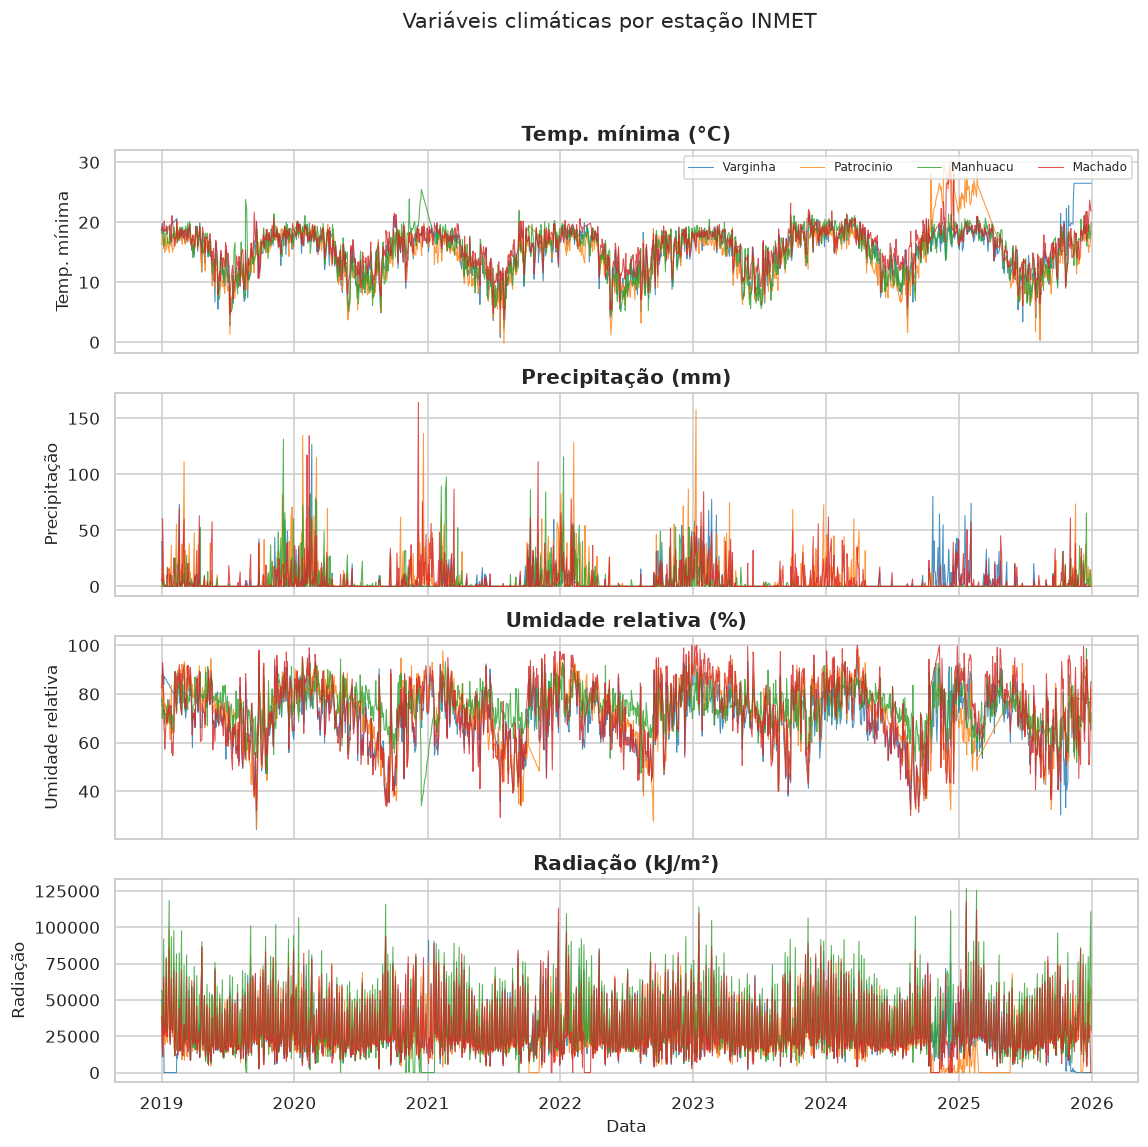


# Comentário: as variáveis climáticas têm forte SAZONALIDADE anual (ciclos regulares). Temperatura mínima cai no inverno (jun-ago), precipitação concentra-se no verão e a radiação acompanha o ciclo solar. As 4 estações se movem de forma parecida, mas Patrocínio/Varginha (mais altas/frias) atingem mínimas menores — relevante p/ geada.


In [14]:
# Séries temporais das principais variáveis climáticas por estação
plot_vars = ["temp_min_C_min", "precip_mm_sum", "umidade_pct_mean", "radiacao_kJm2_sum"]
fig, axes = plt.subplots(len(plot_vars), 1, figsize=(12, 11), sharex=True)
palette = dict(zip(STATIONS, sns.color_palette("tab10", len(STATIONS))))
for ax, var in zip(axes, plot_vars):
    for st in STATIONS:
        col = f"{var}_{st}"
        if col in df.columns:
            ax.plot(df.index, df[col], lw=0.7, alpha=0.8, label=st, color=palette[st])
    ax.set_title(CLIM_PREFIX.get(var, var))
    ax.set_ylabel(CLIM_PREFIX.get(var, var).split("(")[0].strip())
axes[0].legend(ncol=4, fontsize=8, loc="upper right")
axes[-1].set_xlabel("Data")
axes[-1].xaxis.set_major_locator(mdates.YearLocator())
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
fig.suptitle("Variáveis climáticas por estação INMET", y=0.995)
savefig(fig, "08_clima_series.png")
plt.show()

print("\n# Comentário: as variáveis climáticas têm forte SAZONALIDADE anual (ciclos regulares). "
      "Temperatura mínima cai no inverno (jun-ago), precipitação concentra-se no verão e a "
      "radiação acompanha o ciclo solar. As 4 estações se movem de forma parecida, mas "
      "Patrocínio/Varginha (mais altas/frias) atingem mínimas menores — relevante p/ geada.")


  [figura salva] figures/09_sazonalidade_geada.png


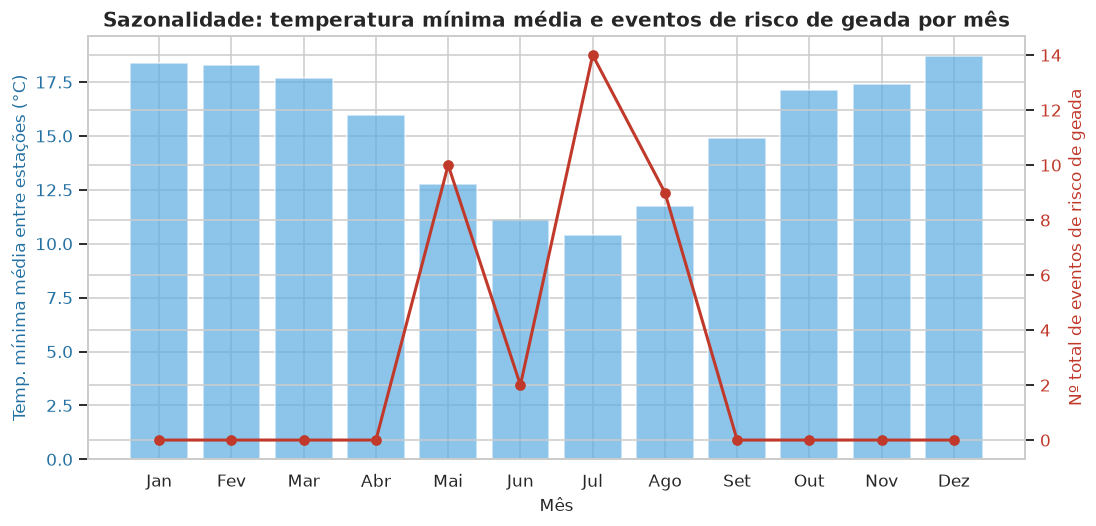


Eventos de risco de geada por estação (total na amostra):
geada_risco_Varginha      12
geada_risco_Patrocinio    19
geada_risco_Manhuacu       1
geada_risco_Machado        3
dtype: int64

# Comentário: os eventos de risco de geada concentram-se no INVERNO (jun-jul-ago), exatamente quando a temperatura mínima média atinge o vale. Patrocínio e Varginha concentram a maioria dos eventos. A geada é um evento RARO e sazonal — poucos episódios na amostra, o que limita o aprendizado direto, mas cada um pode ter impacto desproporcional no preço.


In [15]:
# Sazonalidade: média mensal da temperatura mínima e taxa de eventos de geada por mês
df_m = df.copy()
df_m["mes"] = df_m.index.month
meses = ["Jan","Fev","Mar","Abr","Mai","Jun","Jul","Ago","Set","Out","Nov","Dez"]

tmin_cols = [f"temp_min_C_min_{st}" for st in STATIONS]
geada_cols = [f"geada_risco_{st}" for st in STATIONS]

tmin_month = df_m.groupby("mes")[tmin_cols].mean()
# média da temp. mínima entre estações + risco de geada (proporção de dias com evento) por mês
tmin_avg = tmin_month.mean(axis=1)
geada_month = df_m.groupby("mes")[geada_cols].sum().sum(axis=1)  # total de eventos por mês (todas estações)

fig, ax1 = plt.subplots(figsize=(11, 5))
ax1.bar(range(1,13), tmin_avg.values, color="#5dade2", alpha=0.7, label="Temp. mínima média (°C)")
ax1.set_xticks(range(1,13)); ax1.set_xticklabels(meses)
ax1.set_xlabel("Mês"); ax1.set_ylabel("Temp. mínima média entre estações (°C)", color="#2471a3")
ax1.tick_params(axis="y", labelcolor="#2471a3")

ax2 = ax1.twinx()
ax2.plot(range(1,13), geada_month.values, "o-", color="#c0392b", lw=2, label="Eventos de geada (total)")
ax2.set_ylabel("Nº total de eventos de risco de geada", color="#c0392b")
ax2.tick_params(axis="y", labelcolor="#c0392b")
ax1.set_title("Sazonalidade: temperatura mínima média e eventos de risco de geada por mês")
savefig(fig, "09_sazonalidade_geada.png")
plt.show()

print("\nEventos de risco de geada por estação (total na amostra):")
print(df[geada_cols].sum().astype(int))
print("\n# Comentário: os eventos de risco de geada concentram-se no INVERNO (jun-jul-ago), "
      "exatamente quando a temperatura mínima média atinge o vale. Patrocínio e Varginha "
      "concentram a maioria dos eventos. A geada é um evento RARO e sazonal — poucos episódios "
      "na amostra, o que limita o aprendizado direto, mas cada um pode ter impacto desproporcional no preço.")


  [figura salva] figures/10_preco_geada_overlay.png


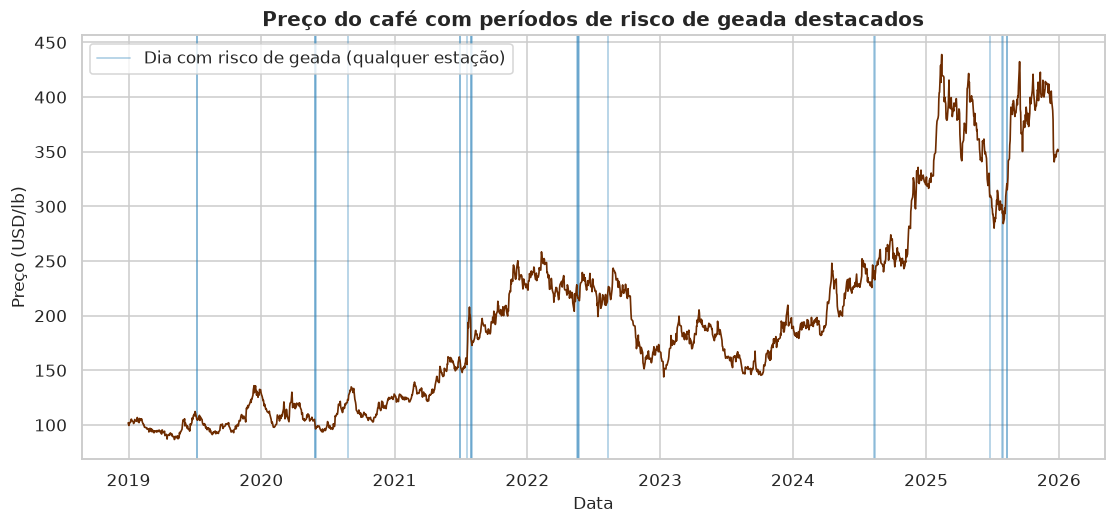


Retorno log médio nos 20 pregões SEGUINTES:
   após dia com risco de geada : +7.18%
   em dias normais             : +1.40%

# Comentário: vários episódios de geada (notadamente 2021, que disparou os preços) coincidem com movimentos de alta. O retorno médio nas semanas seguintes a um dia de risco de geada tende a ser maior que em dias normais, sugerindo efeito DEFASADO e não-instantâneo — a geada danifica a safra futura, e o mercado reprecifica ao longo de semanas.


In [16]:
# Sobrepor períodos de risco de geada sobre a série de preço
df["geada_any"] = (df[geada_cols].sum(axis=1) > 0).astype(int)
geada_dates = df.index[df["geada_any"] == 1]

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df.index, df["preco_cafe"], color="#6e2c00", lw=1.1, zorder=3)
for d in geada_dates:
    ax.axvline(d, color="#2980b9", alpha=0.35, lw=1.2, zorder=1)
# linha fantasma p/ legenda
ax.axvline(geada_dates[0], color="#2980b9", alpha=0.35, lw=1.2, label="Dia com risco de geada (qualquer estação)")
ax.set_title("Preço do café com períodos de risco de geada destacados")
ax.set_xlabel("Data"); ax.set_ylabel("Preço (USD/lb)")
ax.legend(loc="upper left")
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
savefig(fig, "10_preco_geada_overlay.png")
plt.show()

# Resposta do preço em janelas após geada vs. dias normais
fwd = 20
df["ret_fwd"] = np.log(df["preco_cafe"].shift(-fwd) / df["preco_cafe"])
ret_after_geada = df.loc[df["geada_any"]==1, "ret_fwd"].mean()
ret_normal = df.loc[df["geada_any"]==0, "ret_fwd"].mean()
print(f"\nRetorno log médio nos {fwd} pregões SEGUINTES:")
print(f"   após dia com risco de geada : {ret_after_geada*100:+.2f}%")
print(f"   em dias normais             : {ret_normal*100:+.2f}%")
print("\n# Comentário: vários episódios de geada (notadamente 2021, que disparou os preços) "
      "coincidem com movimentos de alta. O retorno médio nas semanas seguintes a um dia de "
      "risco de geada tende a ser maior que em dias normais, sugerindo efeito DEFASADO e "
      "não-instantâneo — a geada danifica a safra futura, e o mercado reprecifica ao longo de semanas.")


## 5. Relações entre variáveis

Correlações (Pearson e Spearman) entre log-retorno, câmbio e variáveis climáticas agregadas
entre as 4 estações.

  [figura salva] figures/11_correlacao.png


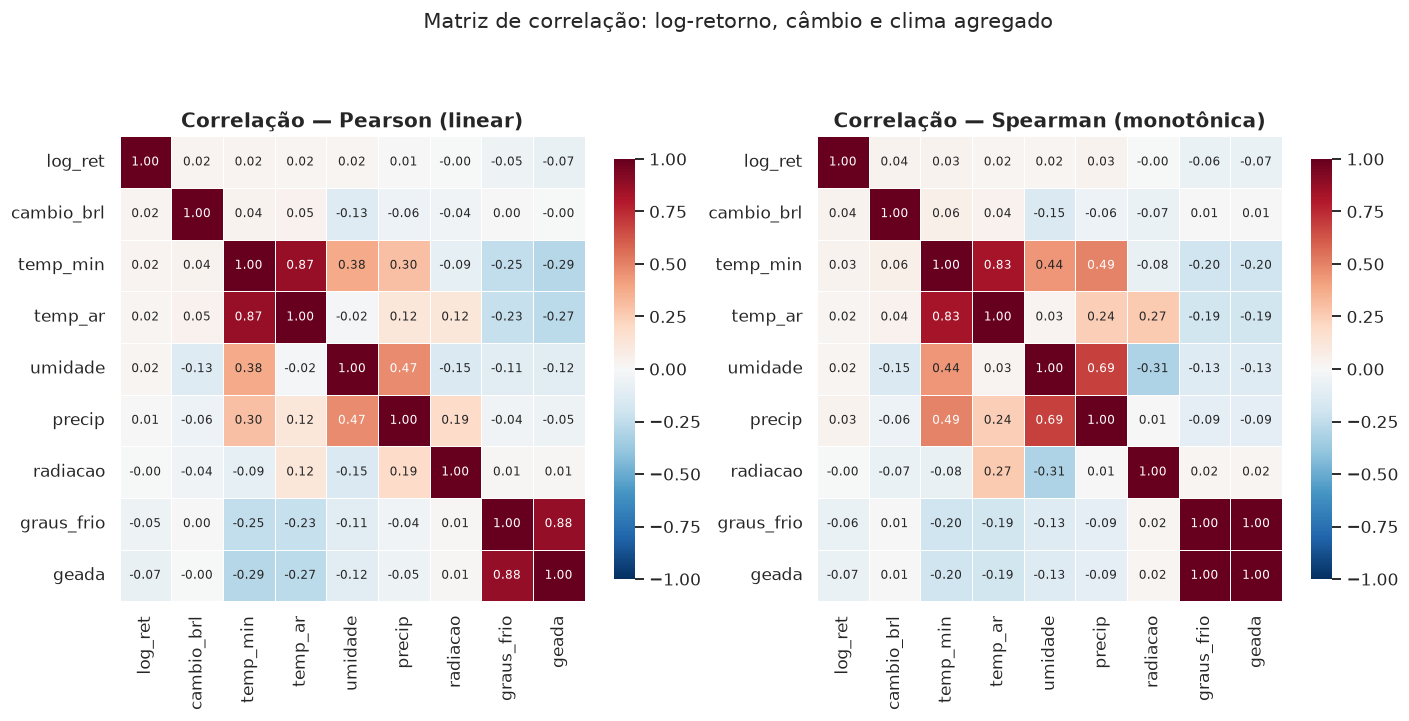


Correlação (Pearson) do log-retorno com as demais variáveis:
geada        -0.074
graus_frio   -0.049
radiacao     -0.004
precip        0.007
umidade       0.017
temp_ar       0.019
cambio_brl    0.024
temp_min      0.024
Name: log_ret, dtype: float64


In [17]:
# Agregar variáveis climáticas entre as 4 estações (média / soma conforme a natureza)
agg = pd.DataFrame(index=df.index)
agg["log_ret"] = df["log_ret"]
agg["cambio_brl"] = df["cambio_brl"]
agg["temp_min"]  = df[[f"temp_min_C_min_{s}" for s in STATIONS]].mean(axis=1)
agg["temp_ar"]   = df[[f"temp_ar_C_mean_{s}" for s in STATIONS]].mean(axis=1)
agg["umidade"]   = df[[f"umidade_pct_mean_{s}" for s in STATIONS]].mean(axis=1)
agg["precip"]    = df[[f"precip_mm_sum_{s}" for s in STATIONS]].mean(axis=1)
agg["radiacao"]  = df[[f"radiacao_kJm2_sum_{s}" for s in STATIONS]].mean(axis=1)
agg["graus_frio"]= df[[f"graus_frio_{s}" for s in STATIONS]].mean(axis=1)
agg["geada"]     = df[[f"geada_risco_{s}" for s in STATIONS]].sum(axis=1)
agg = agg.dropna()

fig, axes = plt.subplots(1, 2, figsize=(15, 6.2))
for ax, method, titulo in zip(axes, ["pearson", "spearman"], ["Pearson (linear)", "Spearman (monotônica)"]):
    corr = agg.corr(method=method)
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
                vmin=-1, vmax=1, square=True, linewidths=.5,
                cbar_kws={"shrink": .8}, ax=ax, annot_kws={"size": 8})
    ax.set_title(f"Correlação — {titulo}")
fig.suptitle("Matriz de correlação: log-retorno, câmbio e clima agregado", y=1.02)
savefig(fig, "11_correlacao.png")
plt.show()

print("\nCorrelação (Pearson) do log-retorno com as demais variáveis:")
print(agg.corr(method="pearson")["log_ret"].drop("log_ret").round(3).sort_values())


In [19]:
print("""# Comentário (relações entre variáveis):
# - O LOG-RETORNO mostra correlação LINEAR muito fraca com câmbio e com todas as variáveis
#   climáticas agregadas (coeficientes próximos de zero, Pearson e Spearman). Ou seja,
#   nenhuma variável explica o retorno do dia de forma contemporânea e linear.
# - Entre as variáveis CLIMÁTICAS há correlações fortes e coerentes fisicamente:
#   temp_min/temp_ar/radiacao positivamente associadas, umidade negativamente associada à
#   temperatura, e graus_frio/geada ligados às mínimas baixas.
# - IMPORTANTE: a ausência de correlação linear NÃO significa ausência de relação. O efeito
#   do clima (sobretudo geada) sobre o preço é (i) não-linear, (ii) por LIMIAR (só importa em
#   eventos extremos), (iii) CUMULATIVO e (iv) DEFASADO em semanas/meses. Uma matriz de
#   correlação contemporânea é cega a isso — justamente o tipo de estrutura que a LSTM, com
#   janelas temporais e não-linearidades, pode capturar.""")


# Comentário (relações entre variáveis):
# - O LOG-RETORNO mostra correlação LINEAR muito fraca com câmbio e com todas as variáveis
#   climáticas agregadas (coeficientes próximos de zero, Pearson e Spearman). Ou seja,
#   nenhuma variável explica o retorno do dia de forma contemporânea e linear.
# - Entre as variáveis CLIMÁTICAS há correlações fortes e coerentes fisicamente:
#   temp_min/temp_ar/radiacao positivamente associadas, umidade negativamente associada à
#   temperatura, e graus_frio/geada ligados às mínimas baixas.
# - IMPORTANTE: a ausência de correlação linear NÃO significa ausência de relação. O efeito
#   do clima (sobretudo geada) sobre o preço é (i) não-linear, (ii) por LIMIAR (só importa em
#   eventos extremos), (iii) CUMULATIVO e (iv) DEFASADO em semanas/meses. Uma matriz de
#   correlação contemporânea é cega a isso — justamente o tipo de estrutura que a LSTM, com
#   janelas temporais e não-linearidades, pode capturar.


## 6. Resumo dos achados da EDA e implicações para a modelagem

**Principais achados:**

1. **Dados completos e densos, mas com forward-fill no clima.** Não há valores faltantes
   (1763 obs., 2018-12-31 a 2025-12-30; único NA é o 1º log-retorno). Porém as variáveis
   climáticas têm poucos valores únicos relativos ao nº de linhas — elas foram repetidas
   (forward-fill) nos dias sem pregão. *Implicação:* cuidado ao tratar o clima como diário
   "fresco"; a informação climática efetiva muda em frequência menor que a do preço.

2. **O nível do preço é não-estacionário; o log-retorno é estacionário** (ADF rejeita raiz
   unitária só no log-retorno). *Implicação:* confirma modelar o **log-retorno** como alvo —
   pré-requisito tanto para ARIMA quanto para estabilidade do treino da LSTM.

3. **Log-retornos são quase simétricos e levemente leptocúrticos** (curtose em excesso ~0.7,
   QQ-plot desviando nos extremos, Jarque-Bera rejeita normalidade — mas o afastamento é
   modesto, não caudas extremas). *Implicação:* prudente não assumir erros estritamente
   Gaussianos e ficar atento a eventos extremos, ainda que o desvio da Normal seja moderado.

4. **Pouca autocorrelação linear na MÉDIA dos retornos** (ACF/PACF dentro das bandas) →
   retornos próximos de ruído branco. *Implicação:* ARIMA de ordem baixa será um baseline
   fraco mas honesto; o ganho preditivo, se houver, virá de estrutura não-linear/exógena.

5. **Forte dependência na VARIÂNCIA — volatility clustering** (ACF dos retornos² significativa;
   volatilidade rolling de 21d alterna regimes calmos/turbulentos). *Implicação:* capturar a
   volatilidade importa (GARCH como baseline de variância; a LSTM pode aprendê-la via janelas).

6. **Clima é fortemente sazonal; geada é evento raro e concentrado no inverno** (jun-ago),
   sobretudo em Patrocínio e Varginha (poucas dezenas de episódios na amostra). *Implicação:*
   features de geada são esparsas; modelar limiar/acúmulo (graus-frio) pode ser mais informativo
   que o flag binário pontual.

7. **Efeito da geada sobre o preço parece DEFASADO, não contemporâneo.** Episódios (ex.: 2021)
   coincidem com altas e o retorno médio nas semanas seguintes a um dia de risco de geada supera
   o de dias normais. *Implicação:* incluir **defasagens/janelas** do clima (e não só o valor do
   dia); é exatamente onde a memória temporal da LSTM pode agregar.

8. **Correlação linear contemporânea entre clima/câmbio e log-retorno é ~nula.** *Implicação:*
   não descartar variáveis por baixa correlação linear — o efeito é não-linear, por limiar,
   cumulativo e defasado. Validar a contribuição das exógenas por desempenho preditivo
   (ablation), não por correlação.

**Em síntese para a modelagem:** alvo = log-retorno (estacionário); baseline ARIMA(baixa ordem)
+ GARCH para volatilidade; LSTM com janelas temporais e features climáticas defasadas/acumuladas;
avaliação robusta a caudas pesadas e atenta a eventos raros (geada).
